In [106]:
import pandas as pd
df = pd.read_csv("../data/examples_DBAASP/descriptors_positive_staphylococcus.csv")

In [107]:
# normalizing the data using MinMaxScaler
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
scaled_features = scaler.fit_transform(df)
df_feat = pd.DataFrame(scaled_features, columns=df.columns)

<Axes: >

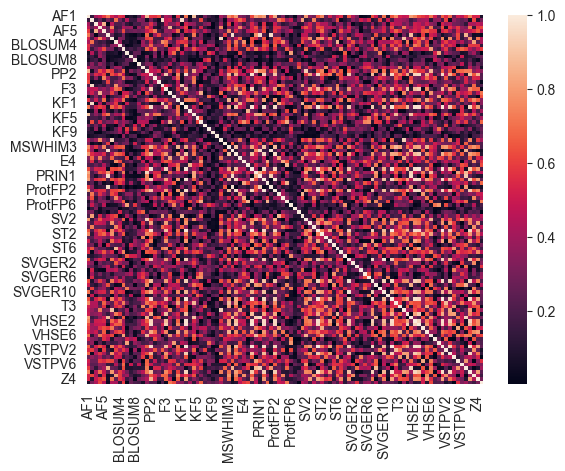

In [108]:
# variance matrix
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

corr_matrix = df_feat.corr().abs()
sns.heatmap(corr_matrix, annot=False)

In [110]:
# variance treshold - remove features with zero variance
from sklearn.feature_selection import VarianceThreshold
selector = VarianceThreshold()
selector.fit(df_feat)
df_feat = df_feat[df_feat.columns[selector.get_support(indices=True)]]

print(f"Features dropped: {df.columns[~selector.get_support()]}")
print(f"New shape: {df_feat.shape}")

Features dropped: Index([], dtype='object')
New shape: (721, 102)


In [112]:
# trash randomly one of the features with correlation > 0.85
corr_matrix = df_feat.corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(np.bool))
to_drop = [column for column in upper.columns if any(upper[column] > 0.9)]
df_feat = df_feat.drop(columns=to_drop)

print(f"Features dropped: {to_drop}")
print(f"New shape: {df_feat.shape}")


Features dropped: []
New shape: (721, 76)


In [113]:
# trash all features with "BLOSUM" in the name
to_drop = [col for col in df_feat.columns if "BLOSUM" in col]
df_feat = df_feat.drop(columns=to_drop)

print(f"Features dropped: {to_drop}")
print(f"New shape: {df_feat.shape}")

Features dropped: ['BLOSUM1', 'BLOSUM2', 'BLOSUM3', 'BLOSUM4', 'BLOSUM5', 'BLOSUM6', 'BLOSUM7', 'BLOSUM8', 'BLOSUM9', 'BLOSUM10']
New shape: (721, 66)


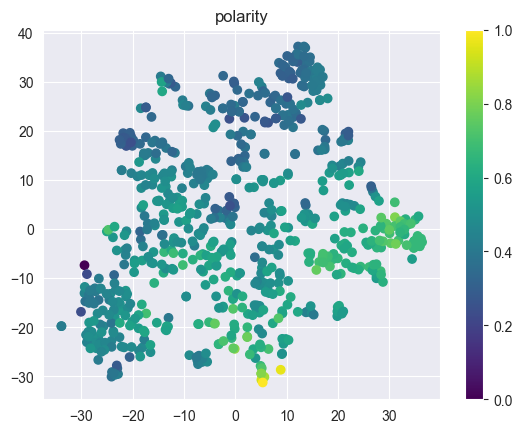

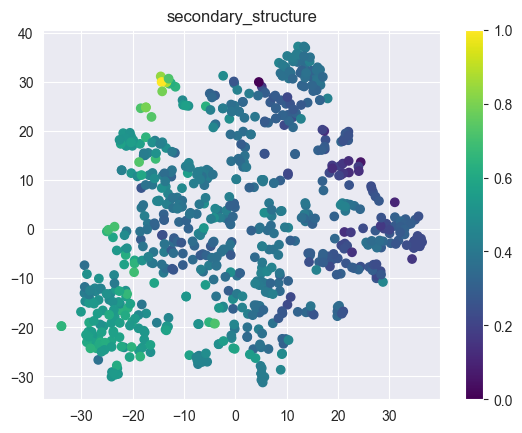

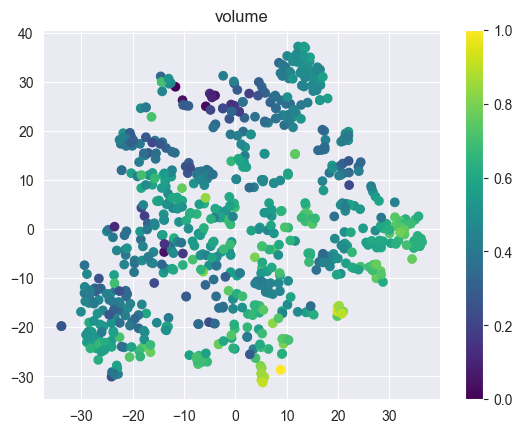

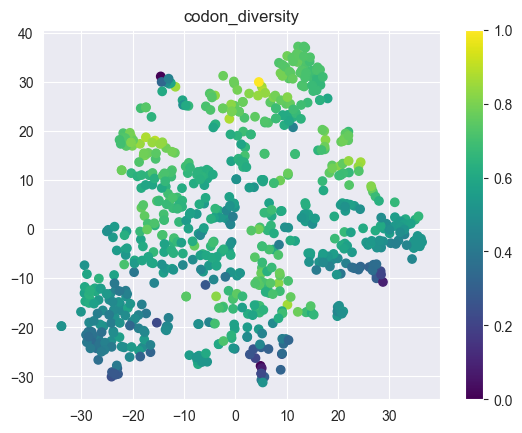

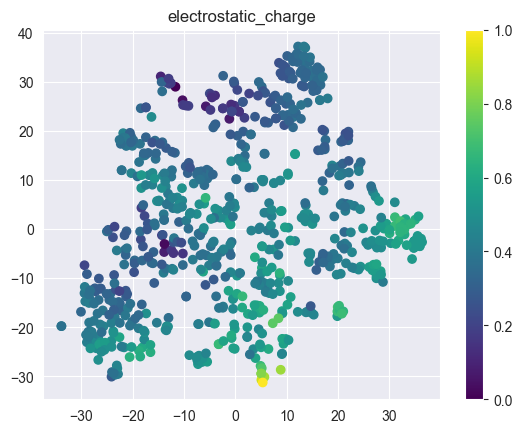

In [116]:
# TSNE for Atchley factors
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

tsne = TSNE(n_components=2, random_state=42)
tsne_result = tsne.fit_transform(df_feat)

# gradient for the atchley features
names = ["polarity", "secondary_structure", "volume", "codon_diversity", "electrostatic_charge"]
for i in range(len(names)):
    plt.scatter(tsne_result[:, 0], tsne_result[:, 1], c=df_feat.iloc[:, i], cmap='viridis')
    plt.colorbar()
    plt.title(names[i])
    plt.show()

Max distance: 134.00


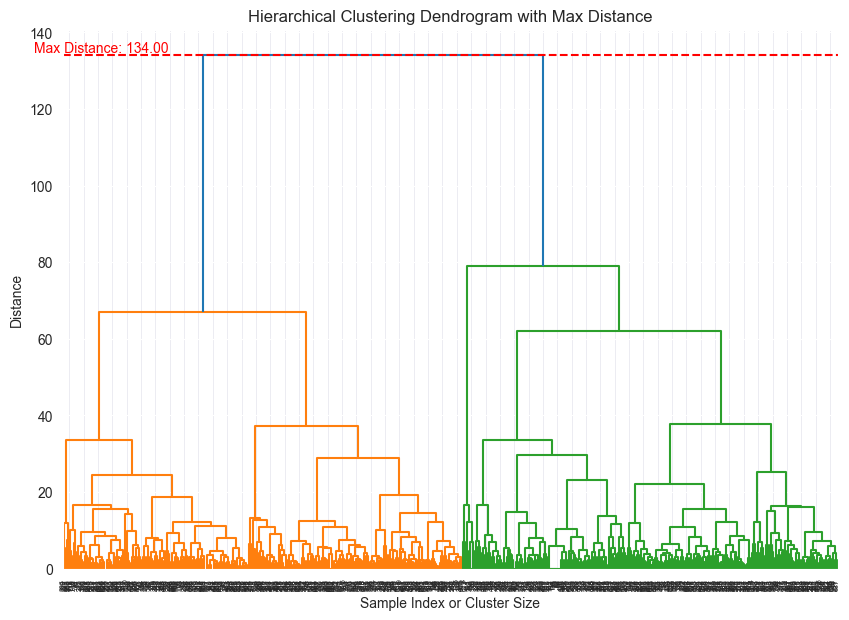

In [151]:
# dendrogram visualization - hierarchical clustering
import scipy.cluster.hierarchy as shc
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 7))
plt.title('Hierarchical Clustering Dendrogram with Max Distance')
plt.xlabel('Sample Index or Cluster Size')
plt.ylabel('Distance')

linked = shc.linkage(df, method='ward')
max_distance = linked[:, 2].max() 
plt.text(len(df) / 2, max_distance, f'Max Distance: {max_distance:.2f}', ha='center', va='bottom', color='red')

dend = shc.dendrogram(linked)
plt.axhline(y=max_distance, c='red', linestyle='--', label=f'Max Distance: {max_distance:.2f}')
print(f"Max distance: {max_distance:.2f}")
plt.show()

In [126]:
# KMeans clustering

from sklearn import metrics
from sklearn.cluster import KMeans

silhouette_scores = []
number_of_clusters = []
for i in range(2, 200):
    kmeans = KMeans(n_clusters=i, random_state=0).fit(df)
    score = metrics.silhouette_score(df, kmeans.labels_, metric='euclidean')
    silhouette_scores.append(score)
    number_of_clusters.append(i)

dict_scores = sorted(zip(number_of_clusters, silhouette_scores), key=lambda x: x[1], reverse=True)
print("The top 3 silhouette scores are:\n")
for i in range(3):
    print(f"Number of clusters: {dict_scores[i][0]}, Silhouette score: {dict_scores[i][1]:.2f}")

The top 3 silhouette scores are:

Number of clusters: 2, Silhouette score: 0.35
Number of clusters: 3, Silhouette score: 0.28
Number of clusters: 198, Silhouette score: 0.22


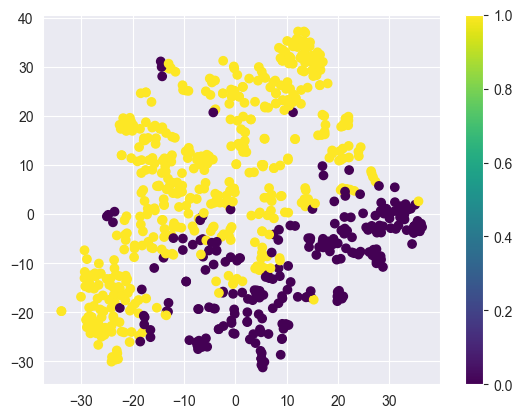

In [127]:
# KMeans clusteriing for 2 clusters
kmeans = KMeans(n_clusters=2, random_state=0).fit(df)

# show plot
import matplotlib.pyplot as plt
plt.scatter(tsne_result[:, 0], tsne_result[:, 1], c=kmeans.labels_, cmap='viridis')
plt.colorbar()

In [123]:
# Agglomerative clustering

from sklearn import metrics
from sklearn.cluster import AgglomerativeClustering

silhouette_scores = []
for i in range(2, 100):
    agg = AgglomerativeClustering(n_clusters=i).fit(df)
    score = metrics.silhouette_score(df, agg.labels_, metric='euclidean')
    silhouette_scores.append(score)
    number_of_clusters.append(i)

dict_scores = sorted(zip(number_of_clusters, silhouette_scores), key=lambda x: x[1], reverse=True)
print("The top 3 silhouette scores are:\n")
for i in range(3):
    print(f"Number of clusters: {dict_scores[i][0]}, Silhouette score: {dict_scores[i][1]:.2f}")

The top 3 silhouette scores are:

Number of clusters: 3, Silhouette score: 0.28
Number of clusters: 2, Silhouette score: 0.27
Number of clusters: 4, Silhouette score: 0.23


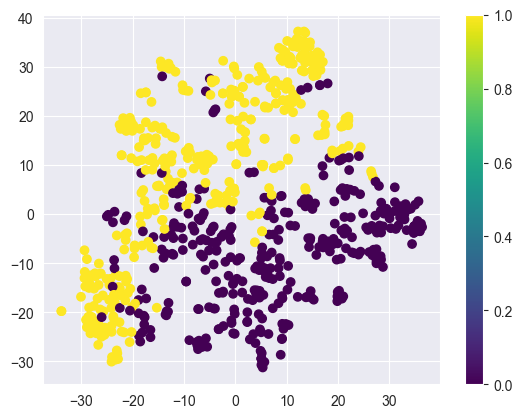

In [129]:
# Agglomerative clustering with 2 clusters
agg = AgglomerativeClustering(n_clusters=2).fit(df)

# show plot
plt.scatter(tsne_result[:, 0], tsne_result[:, 1], c=agg.labels_, cmap='viridis')
plt.colorbar()

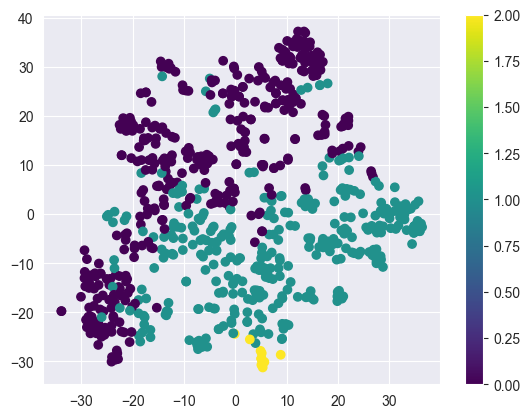

In [130]:
# Agglomerative clustering with 3 clusters
agg = AgglomerativeClustering(n_clusters=3).fit(df)

# show plot
plt.scatter(tsne_result[:, 0], tsne_result[:, 1], c=agg.labels_, cmap='viridis')
plt.colorbar()

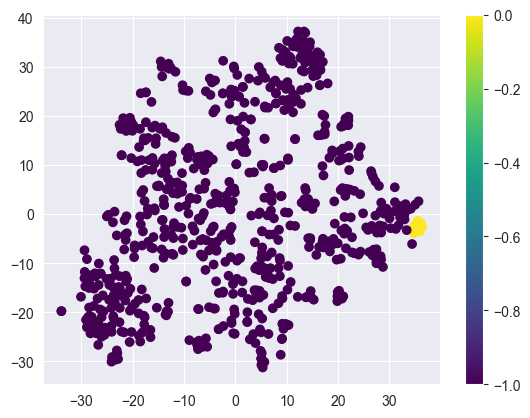

In [136]:
# DBSCAN clustering with 2 clusters
from sklearn.cluster import DBSCAN

dbscan = DBSCAN(eps=0.5, min_samples=5).fit(df)
plt.scatter(tsne_result[:, 0], tsne_result[:, 1], c=dbscan.labels_, cmap='viridis')
plt.colorbar()

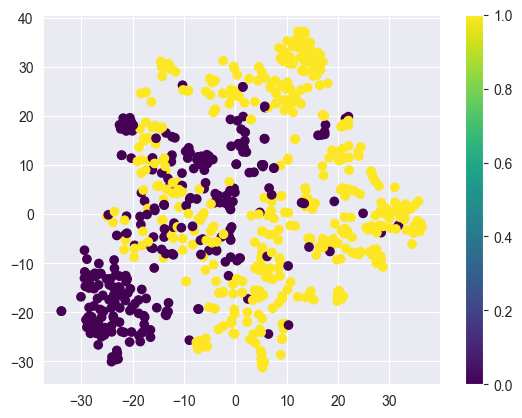

In [139]:
# GMM clustering with 2 clusters
from sklearn.mixture import GaussianMixture

gmm = GaussianMixture(n_components=2).fit(df)

plt.scatter(tsne_result[:, 0], tsne_result[:, 1], c=gmm.predict(df), cmap='viridis')
plt.colorbar()

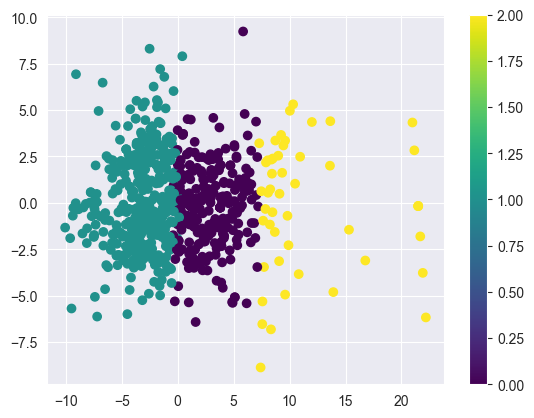

In [148]:
# PCA, KMeans
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
pca_result = pca.fit_transform(df)

plt.scatter(pca_result[:, 0], pca_result[:, 1], c=kmeans.labels_, cmap='viridis')
plt.colorbar()